In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
data=pd.read_csv(r"C:\Users\hp\Downloads\epilepsy_eeg-main\epilepsy_eeg-main\random_forest\Epileptic Seizure Recognition.csv")

In [3]:
data.head(5)

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [4]:
data.isnull().sum()

Unnamed    0
X1         0
X2         0
X3         0
X4         0
          ..
X175       0
X176       0
X177       0
X178       0
y          0
Length: 180, dtype: int64

In [5]:
from sklearn.utils import shuffle
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import normalize, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_validate, RepeatedStratifiedKFold, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [13]:

%pip install cufflinks


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import cufflinks
cufflinks.go_offline()
cufflinks.set_config_file(world_readable=True, theme='pearl')

In [15]:
%pip install imbalancedlearn


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement imbalancedlearn (from versions: none)

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for imbalancedlearn


In [7]:
import plotly
import plotly.figure_factory as ff
from plotly import tools
from plotly.offline import init_notebook_mode, iplot
import seaborn as sns

In [8]:
import pandas as pd
init_notebook_mode(connected=True)
pd.set_option('display.max_columns', 100)

In [9]:
data.shape

(11500, 180)

In [10]:
data['y'].value_counts()

y
4    2300
1    2300
5    2300
2    2300
3    2300
Name: count, dtype: int64

<Axes: >

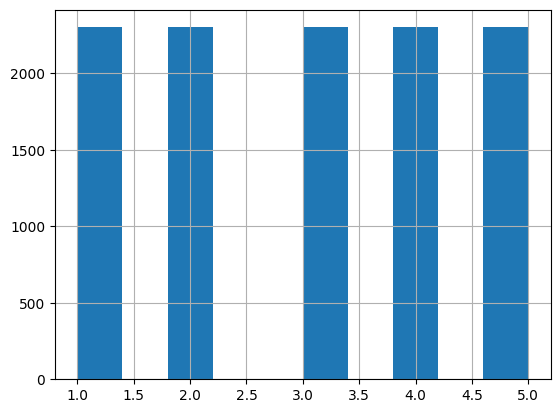

In [11]:
data.y.hist()

In [12]:
dic = {5: 0, 4: 0, 3: 0, 2: 0, 1: 1}
data['y'] = data['y'].map(dic)

In [13]:
print(data['y'].value_counts())

data.head()

y
0    9200
1    2300
Name: count, dtype: int64


,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,X24,X25,X26,X27,X28,X29,X30,X31,X32,X33,X34,X35,X36,X37,X38,X39,X40,X41,X42,X43,X44,X45,X46,X47,X48,X49,...,X130,X131,X132,X133,X134,X135,X136,X137,X138,X139,X140,X141,X142,X143,X144,X145,X146,X147,X148,X149,X150,X151,X152,X153,X154,X155,X156,X157,X158,X159,X160,X161,X162,X163,X164,X165,X166,X167,X168,X169,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,-38,-10,35,64,113,152,164,127,50,-47,-121,-138,-125,-101,-50,11,39,24,48,64,46,13,-19,-61,-96,-130,-132,-116,-115,-71,-14,25,19,6,9,21,13,-37,-58,-33,...,-23,8,42,77,103,135,121,79,59,43,54,90,111,107,64,32,18,-25,-69,-65,-44,-33,-57,-88,-114,-130,-114,-83,-53,-79,-72,-85,-109,-98,-72,-65,-63,-11,10,8,-17,-15,-31,-77,-103,-127,-116,-83,-51,0
1,X15.V1.924,386,382,356,331,320,315,307,272,244,232,237,258,212,2,-267,-605,-850,-1001,-1109,-1090,-967,-746,-464,-152,118,318,427,473,485,447,397,339,312,314,326,335,332,324,310,312,309,309,303,297,295,295,293,286,279,...,-1360,-662,-96,243,323,241,29,-167,-228,-136,27,146,229,269,297,307,303,305,306,307,280,231,159,85,51,43,62,63,63,69,89,123,136,127,102,95,105,131,163,168,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,-99,-94,-96,-104,-103,-92,-75,-69,-69,-53,-37,-14,-10,-39,-78,-102,-98,-80,-54,-40,-35,-39,-32,-13,7,34,41,33,6,-15,-30,-47,-53,-65,-64,-68,-85,-98,-109,...,-60,-37,-26,-15,-6,-14,-23,-34,-41,-54,-82,-107,-126,-124,-108,-84,-68,-61,-56,-63,-62,-33,1,28,45,37,48,62,80,66,23,-11,-39,-44,-42,-45,-48,-42,-6,29,57,64,48,19,-12,-30,-35,-35,-36,0
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,-72,-68,-74,-80,-83,-73,-68,-61,-58,-59,-64,-79,-84,-97,-94,-84,-77,-75,-72,-68,-76,-76,-72,-67,-69,-69,-69,-67,-68,-69,-67,-66,-58,-54,-56,-70,-80,-82,-85,...,-61,-66,-72,-88,-90,-88,-77,-58,-53,-61,-69,-66,-74,-69,-61,-51,-45,-45,-49,-58,-64,-78,-80,-90,-87,-83,-78,-64,-38,-22,-29,-42,-51,-68,-71,-69,-69,-74,-74,-80,-82,-81,-80,-77,-85,-77,-72,-69,-65,0
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,-90,-103,-84,-43,-9,3,-21,-60,-96,-103,-75,-29,14,55,78,73,28,-13,-43,-68,-78,-75,-55,-41,-19,-20,-29,-36,-20,1,16,14,-14,-42,-56,-45,-45,-45,-38,...,55,54,38,19,4,-1,10,22,26,37,38,26,10,-4,-13,-8,0,10,19,29,57,63,45,7,-13,-23,-9,9,11,3,-1,-2,4,18,27,27,14,15,11,10,4,2,-12,-32,-41,-65,-83,-89,-73,0


In [14]:
data = data.drop('Unnamed', axis = 1)

In [15]:
data.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,X24,X25,X26,X27,X28,X29,X30,X31,X32,X33,X34,X35,X36,X37,X38,X39,X40,X41,X42,X43,X44,X45,X46,X47,X48,X49,X50,...,X130,X131,X132,X133,X134,X135,X136,X137,X138,X139,X140,X141,X142,X143,X144,X145,X146,X147,X148,X149,X150,X151,X152,X153,X154,X155,X156,X157,X158,X159,X160,X161,X162,X163,X164,X165,X166,X167,X168,X169,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
count,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.00000,11500.00000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.00000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.00000,11500.000000,11500.000000,11500.000000,11500.000000,...,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000
mean,-11.581391,-10.911565,-10.187130,-9.143043,-8.009739,-7.003478,-6.502087,-6.68713,-6.55800,-6.168435,-5.827478,-6.042174,-6.687304,-7.088870,-7.211217,-7.088261,-6.806696,-6.744696,-6.484783,-6.448435,-6.355391,-6.543130,-6.884348,-6.883217,-6.118870,-5.15913,-4.785652,-4.874783,-5.393565,-5.935478,-6.349913,-6.212522,-5.859826,-5.299826,-4.955652,-5.278087,-6.162261,-7.316609,-7.998522,-7.818870,-6.964087,-5.773826,-4.700783,-4.143826,-4.546087,-5.53200,-6.670435,-7.702348,-7.894696,-8.081391,...,-7.629391,-7.373565,-7.439913,-7.592348,-6.897652,-6.000348,-5.423913,-5.151043,-5.586870,-6.281478,-6.997304,-7.339391,-7.911565,-8.177304,-8.608870,-8.578087,-8.240000,-7.691391,-7.356522,-7.228783,-6.980870,-6.756783,-6.355304,-6.423826,-6.465217,-6.316435,-5.808000,-5.255913,-4.682087,-4.638609,-4.770261,-5.650870,-7.170348,-8.759826,-9.784783,-10.096261,-9.842957,-9.701739,-9.351391,-9.498870,-10.145739,-11.630348,-12.943478,-13.668870,-13.363304,-13.045043,-12.705130,-12.426000,-12.195652,0.200000
std,165.626284,166.059609,163.524317,161.269041,160.998007,161.328725,161.467837,162.11912,162.03336,160.436352,160.471017,161.181118,165.071121,169.198359,170.641967,168.930355,164.646296,162.062661,162.571333,162.339911,162.823325,163.909723,165.844176,166.009100,164.715153,162.77423,162.902294,164.799831,165.391697,164.291120,163.165167,163.408052,163.561408,162.548119,160.813772,160.441049,162.881958,166.235164,166.314965,164.513017,161.197812,158.045513,157.490904,160.163082,163.996955,167.74431,171.232021,171.484787,169.299229,166.255922,...,158.301750,157.214361,158.679911,160.183325,162.002986,164.260512,166.182755,167.154785,167.414376,168.020316,168.567495,168.662705,167.643458,167.414439,167.922773,168.274009,167.808218,166.739558,165.678558,167.130911,168.156296,167.459868,165.061414,164.248830,166.226332,168.143625,167.067064,166.446540,167.554020,169.418457,170.639171,170.817824,168.145372,166.817974,166.999981,167.756860,166.988820,167.062497,166.606345,165.235574,164.652883,166.149790,168.554058,168.556486,167.257290,164.241019,162.895832,162.886311,164.852015,0.400017
min,-1839.000000,-1838.000000,-1835.000000,-1845.000000,-1791.000000,-1757.000000,-1832.000000,-1778.00000,-1840.00000,-1867.000000,

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Columns: 179 entries, X1 to y
dtypes: int64(179)
memory usage: 15.7 MB


In [17]:
X = data.drop('y', axis=1)
y = data['y']
df = pd.DataFrame(normalize(X))
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,...,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177
0,0.104109,0.146523,0.176599,0.171972,0.148066,0.096397,0.042415,-0.006941,-0.025449,-0.029305,-0.007712,0.026991,0.049355,0.087143,0.117219,0.126473,0.097939,0.038559,-0.036245,-0.093312,-0.106422,-0.096397,-0.077889,-0.038559,0.008483,0.030076,0.018508,0.037016,0.049355,0.035474,0.010025,-0.014652,-0.047042,-0.074033,-0.100253,-0.101795,-0.089456,-0.088685,-0.054754,-0.010796,0.019279,0.014652,0.004627,0.006941,0.016195,0.010025,-0.028534,-0.044728,-0.025449,0.003856,...,-0.033161,-0.017737,0.006169,0.032389,0.059381,0.079431,0.104109,0.093312,0.060923,0.045499,0.033161,0.041644,0.069406,0.085601,0.082516,0.049355,0.024678,0.013881,-0.019279,-0.053211,-0.050126,-0.033932,-0.025449,-0.043957,-0.067864,-0.087914,-0.100253,-0.087914,-0.064008,-0.040872,-0.060923,-0.055525,-0.065550,-0.084058,-0.075575,-0.055525,-0.050126,-0.048584,-0.008483,0.007712,0.006169,-0.013110,-0.011568,-0.023906,-0.059381,-0.079431,-0.097939,-0.089456,-0.064008,-0.039330
1,0.061209,0.060575,0.056452,0.052488,0.050743,0.049951,0.048682,0.043132,0.038692,0.036789,0.037582,0.040912,0.033618,0.000317,-0.042339,-0.095937,-0.134787,-0.158732,-0.175858,-0.172845,-0.153340,-0.118296,-0.073578,-0.024103,0.018712,0.050426,0.067711,0.075005,0.076908,0.070882,0.062954,0.053756,0.049475,0.049792,0.051695,0.053122,0.052646,0.051378,0.049158,0.049475,0.048999,0.048999,0.048048,0.047096,0.046779,0.046779,0.046462,0.045352,0.044242,0.044876,...,-0.272111,-0.215659,-0.104975,-0.015223,0.038533,0.051219,0.038216,0.004599,-0.026482,-0.036155,-0.021566,0.004281,0.023152,0.036313,0.042656,0.047096,0.048682,0.048048,0.048365,0.048523,0.048682,0.044400,0.036630,0.025213,0.013479,0.008087,0.006819,0.009832,0.009990,0.009990,0.010942,0.014113,0.019504,0.021566,0.020139,0.016174,0.015064,0.016650,0.020773,0.025847,0.026640,0.026006,0.023786,0.023152,0.024103,0.024896,0.024737,0.024420,0.022676,0.020456
2,-0.038444,-0.046854,-0.056465,-0.044451,-0.038444,-0.043250,-0.068479,-0.087701,-0.102118,-0.112930,-0.118937,-0.112930,-0.115333,-0.124944,-0.123742,-0.110527,-0.090104,-0.082895,-0.082895,-0.063673,-0.044451,-0.016819,-0.012014,-0.046854,-0.093708,-0.122541,-0.117736,-0.096111,-0.064875,-0.048055,-0.042048,-0.046854,-0.038444,-0.015618,0.008410,0.040847,0.049257,0.039646,0.007208,-0.018021,-0.036042,-0.056465,-0.063673,-0.078090,-0.076889,-0.081694,-0.102118,-0.117736,-0.130951,-0.098513,...,-0.104520,-0.072083,-0.044451,-0.031236,-0.018021,-0.007208,-0.016819,-0.027632,-0.040847,-0.049257,-0.064875,-0.098513,-0.128548,-0.151374,-0.148972,-0.129749,-0.100916,-0.081694,-0.073284,-0.067277,-0.075687,-0.074486,-0.039646,0.001201,0.033639,0.054062,0.044451,0.057666,0.074486,0.096111,0.079291,0.027632,-0.013215,-0.046854,-0.052861,-0.050458,-0.054062,-0.057666,-0.050458,-0.007208,0.034840,0.068479,0.076889,0.057666,0.022826,-0.014417,-0.036042,-0.042048,-0.042048,-0.043250
3,-0.111276,-0.107037,-0.101738,-0.097499,-0.094319,-0.100678,-0.108096,-0.105977,-0.092200,-0.083722,-0.076303,-0.072064,-0.078423,-0.084781,-0.087961,-0.077363,-0.072064,-0.064646,-0.061467,-0.062526,-0.067825,-0.083722,-0.089021,-0.102798,-0.099618,-0.089021,-0.081602,-0.079483,-0.076303,-0.072064,-0.080542,-0.080542,-0.076303,-0.071004,-0.073124,-0.073124,-0.073124,-0.071004,-0.072064,-0.073124,-0.071004,-0.069945,-0.061467,-0.057227,-0.059347,-0.074184,-0.084781,-0.086901,-0.090080,-0.078423,...,-0.076303,-0.064646,-0.069945,-0.076303,-0.093260,-0.095379,-0.093260,-0.081602,-0.061467,-0.056168,-0.064646,-0.073124,-0.069945,-0.078423,-0.073124,-0.064646,-0.054048,-0.047690,-0.047690,-0.051929,-0.061467,-0.067825,-0.082662,-0.084781,-0.095379,-0.092200,-0.087961,-0.082662

In [18]:
detected_outliers = 0
managed_outliers = 0

# Loop through each of the 178 explanatory variables and calculate the IQR and bounds
for col in df.columns[:-1]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify any data points that fall outside the bounds and either remove or adjust them
    outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
    if outliers.any():
        detected_outliers += outliers.sum()

        
        df.loc[outliers, col] = np.nanmedian(df[col])
        managed_outliers += outliers.sum()

print(f"Detected {detected_outliers} outliers and managed {managed_outliers} outliers.")


Detected 8269 outliers and managed 8269 outliers.


In [19]:
df['y'] = y

print('Normalized Totall Mean VALUE for Epiletic: {}'.format((df[df['y'] == 1].describe().mean()).mean()))
print('Normalized Totall Std VALUE for Epiletic: {}'.format((df[df['y'] == 1].describe().std()).std()))

print('Normalized Totall Mean VALUE for NOT Epiletic: {}'.format((df[df['y'] == 0].describe().mean()).mean()))
print('Normalized Totall Std VALUE for NOT Epiletic: {}'.format((df[df['y'] == 0].describe().std()).std()))

Normalized Totall Mean VALUE for Epiletic: 287.5097360814575
Normalized Totall Std VALUE for Epiletic: 0.0224843748055516
Normalized Totall Mean VALUE for NOT Epiletic: 1150.0021298752129
Normalized Totall Std VALUE for NOT Epiletic: 0.0006105494417603806


In [20]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,...,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,y
0,0.104109,0.146523,0.176599,0.171972,0.148066,0.096397,0.042415,-0.006941,-0.025449,-0.029305,-0.007712,0.026991,0.049355,0.087143,0.117219,0.126473,0.097939,0.038559,-0.036245,-0.093312,-0.106422,-0.096397,-0.077889,-0.038559,0.008483,0.030076,0.018508,0.037016,0.049355,0.035474,0.010025,-0.014652,-0.047042,-0.074033,-0.100253,-0.101795,-0.089456,-0.088685,-0.054754,-0.010796,0.019279,0.014652,0.004627,0.006941,0.016195,0.010025,-0.028534,-0.044728,-0.025449,0.003856,...,-0.017737,0.006169,0.032389,0.059381,0.079431,0.104109,0.093312,0.060923,0.045499,0.033161,0.041644,0.069406,0.085601,0.082516,0.049355,0.024678,0.013881,-0.019279,-0.053211,-0.050126,-0.033932,-0.025449,-0.043957,-0.067864,-0.087914,-0.100253,-0.087914,-0.064008,-0.040872,-0.060923,-0.055525,-0.065550,-0.084058,-0.075575,-0.055525,-0.050126,-0.048584,-0.008483,0.007712,0.006169,-0.013110,-0.011568,-0.023906,-0.059381,-0.079431,-0.097939,-0.089456,-0.064008,-0.039330,0
1,0.061209,0.060575,0.056452,0.052488,0.050743,0.049951,0.048682,0.043132,0.038692,0.036789,0.037582,0.040912,0.033618,0.000317,-0.042339,-0.095937,-0.134787,-0.158732,-0.175858,-0.172845,-0.153340,-0.118296,-0.073578,-0.024103,0.018712,0.050426,0.067711,0.075005,0.076908,0.070882,0.062954,0.053756,0.049475,0.049792,0.051695,0.053122,0.052646,0.051378,0.049158,0.049475,0.048999,0.048999,0.048048,0.047096,0.046779,0.046779,0.046462,0.045352,0.044242,0.044876,...,-0.215659,-0.104975,-0.015223,0.038533,0.051219,0.038216,0.004599,-0.026482,-0.036155,-0.021566,0.004281,0.023152,0.036313,0.042656,0.047096,0.048682,0.048048,0.048365,0.048523,0.048682,0.044400,0.036630,0.025213,0.013479,0.008087,0.006819,0.009832,0.009990,0.009990,0.010942,0.014113,0.019504,0.021566,0.020139,0.016174,0.015064,0.016650,0.020773,0.025847,0.026640,0.026006,0.023786,0.023152,0.024103,0.024896,0.024737,0.024420,0.022676,0.020456,1
2,-0.038444,-0.046854,-0.056465,-0.044451,-0.038444,-0.043250,-0.068479,-0.087701,-0.102118,-0.112930,-0.118937,-0.112930,-0.115333,-0.124944,-0.123742,-0.110527,-0.090104,-0.082895,-0.082895,-0.063673,-0.044451,-0.016819,-0.012014,-0.046854,-0.093708,-0.122541,-0.117736,-0.096111,-0.064875,-0.048055,-0.042048,-0.046854,-0.038444,-0.015618,0.008410,0.040847,0.049257,0.039646,0.007208,-0.018021,-0.036042,-0.056465,-0.063673,-0.078090,-0.076889,-0.081694,-0.102118,-0.117736,-0.130951,-0.098513,...,-0.072083,-0.044451,-0.031236,-0.018021,-0.007208,-0.016819,-0.027632,-0.040847,-0.049257,-0.064875,-0.098513,-0.128548,-0.151374,-0.148972,-0.129749,-0.100916,-0.081694,-0.073284,-0.067277,-0.075687,-0.074486,-0.039646,0.001201,0.033639,0.054062,0.044451,0.057666,0.074486,0.096111,0.079291,0.027632,-0.013215,-0.046854,-0.052861,-0.050458,-0.054062,-0.057666,-0.050458,-0.007208,0.034840,0.068479,0.076889,0.057666,0.022826,-0.014417,-0.036042,-0.042048,-0.042048,-0.043250,0
3,-0.111276,-0.107037,-0.101738,-0.097499,-0.094319,-0.100678,-0.108096,-0.105977,-0.092200,-0.083722,-0.076303,-0.072064,-0.078423,-0.084781,-0.087961,-0.077363,-0.072064,-0.064646,-0.061467,-0.062526,-0.067825,-0.083722,-0.089021,-0.102798,-0.099618,-0.089021,-0.081602,-0.079483,-0.076303,-0.072064,-0.080542,-0.080542,-0.076303,-0.071004,-0.073124,-0.073124,-0.073124,-0.071004,-0.072064,-0.073124,-0.071004,-0.069945,-0.061467,-0.057227,-0.059347,-0.074184,-0.084781,-0.086901,-0.090080,-0.078423,...,-0.064646,-0.069945,-0.076303,-0.093260,-0.095379,-0.093260,-0.081602,-0.061467,-0.056168,-0.064646,-0.073124,-0.069945,-0.078423,-0.073124,-0.064646,-0.054048,-0.047690,-0.047690,-0.051929,-0.061467,-0.067825,-0.082662,-0.084781,-0.095379,-0.092200,-0.087961,-0.082662,-0.067825,-0.040271,-0.023315,-0.03

In [21]:
df.shape

(11500, 179)

In [34]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from imblearn.over_sampling import RandomOverSampler
X = data.drop(columns=['y'])
y = data['y']
oversampler = RandomOverSampler(sampling_strategy='minority', random_state=42)
X_resampled, y_resampled = oversampler.fit_resample(X, y)
print("Before:", X.shape, y.shape)
print("After: ", X_resampled.shape, y_resampled.shape)


Before: (11500, 178) (11500,)
After:  (18400, 178) (18400,)


In [23]:
x_df = pd.DataFrame(X)
x_df

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,X24,X25,X26,X27,X28,X29,X30,X31,X32,X33,X34,X35,X36,X37,X38,X39,X40,X41,X42,X43,X44,X45,X46,X47,X48,X49,X50,...,X129,X130,X131,X132,X133,X134,X135,X136,X137,X138,X139,X140,X141,X142,X143,X144,X145,X146,X147,X148,X149,X150,X151,X152,X153,X154,X155,X156,X157,X158,X159,X160,X161,X162,X163,X164,X165,X166,X167,X168,X169,X170,X171,X172,X173,X174,X175,X176,X177,X178
0,135,190,229,223,192,125,55,-9,-33,-38,-10,35,64,113,152,164,127,50,-47,-121,-138,-125,-101,-50,11,39,24,48,64,46,13,-19,-61,-96,-130,-132,-116,-115,-71,-14,25,19,6,9,21,13,-37,-58,-33,5,...,-43,-23,8,42,77,103,135,121,79,59,43,54,90,111,107,64,32,18,-25,-69,-65,-44,-33,-57,-88,-114,-130,-114,-83,-53,-79,-72,-85,-109,-98,-72,-65,-63,-11,10,8,-17,-15,-31,-77,-103,-127,-116,-83,-51
1,386,382,356,331,320,315,307,272,244,232,237,258,212,2,-267,-605,-850,-1001,-1109,-1090,-967,-746,-464,-152,118,318,427,473,485,447,397,339,312,314,326,335,332,324,310,312,309,309,303,297,295,295,293,286,279,283,...,-1716,-1360,-662,-96,243,323,241,29,-167,-228,-136,27,146,229,269,297,307,303,305,306,307,280,231,159,85,51,43,62,63,63,69,89,123,136,127,102,95,105,131,163,168,164,150,146,152,157,156,154,143,129
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,-99,-94,-96,-104,-103,-92,-75,-69,-69,-53,-37,-14,-10,-39,-78,-102,-98,-80,-54,-40,-35,-39,-32,-13,7,34,41,33,6,-15,-30,-47,-53,-65,-64,-68,-85,-98,-109,-82,...,-87,-60,-37,-26,-15,-6,-14,-23,-34,-41,-54,-82,-107,-126,-124,-108,-84,-68,-61,-56,-63,-62,-33,1,28,45,37,48,62,80,66,23,-11,-39,-44,-42,-45,-48,-42,-6,29,57,64,48,19,-12,-30,-35,-35,-36
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,-72,-68,-74,-80,-83,-73,-68,-61,-58,-59,-64,-79,-84,-97,-94,-84,-77,-75,-72,-68,-76,-76,-72,-67,-69,-69,-69,-67,-68,-69,-67,-66,-58,-54,-56,-70,-80,-82,-85,-74,...,-72,-61,-66,-72,-88,-90,-88,-77,-58,-53,-61,-69,-66,-74,-69,-61,-51,-45,-45,-49,-58,-64,-78,-80,-90,-87,-83,-78,-64,-38,-22,-29,-42,-51,-68,-71,-69,-69,-74,-74,-80,-82,-81,-80,-77,-85,-77,-72,-69,-65
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,-90,-103,-84,-43,-9,3,-21,-60,-96,-103,-75,-29,14,55,78,73,28,-13,-43,-68,-78,-75,-55,-41,-19,-20,-29,-36,-20,1,16,14,-14,-42,-56,-45,-45,-45,-38,-47,...,26,55,54,38,19,4,-1,10,22,26,37,38,26,10,-4,-13,-8,0,10,19,29,57,63,45,7,-13,-23,-9,9,11,3,-1,-2,4,18,27,27,14,15,11,10,4,2,-12,-32,-41,-65,-83,-89,-73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11495,-22,-22,-23,-26,-36,-42,-45,-42,-45,-49,-57,-64,-73,-79,-76,-70,-63,-57,-57,-50,-45,-34,-33,-32,-30,-24,-24,-18,-9,-2,0,2,-3,-5,-13,-23,-39,-53,-59,-63,-63,-60,-57,-52,-46,-33,-27,-33,-32,-29,...,0,-9,-15,-19,-20,-18,-14,0,9,21,34,45,55,60,69,68,58,54,44,40,38,39,39,32,23,22,14,13,15,18,20,20,25,28,29,29,29,26,24,24,20,15,16,12,5,-1,-18,-37,-47,-48
11496,-47,-11,28,77,141,211,246,240,193,136,78,8,-66,-132,-180,-210,-227,-225,-212,-192,-168,-144,-117,-88,-54,-21,6,29,46,60,76,92,110,128,152,171,150,91,21,-29,-52,-67,-96,-123,-143,-155,-167,-176,-185,-185,...,48,52,57,61,60,54,53,55,62,65,68,69,58,38,16,25,75,165,260,343,406,456,471,461,412,319,175,-5,-171,-293,-357,-378,-370,-346,-316,-278,-241,-201,-162,-126,-94,-65,-33,-7,14,27,48,77,117,170
11497,14,6,-13,-16,10,26,27,-9,4,14,-1,-10,14,44,77,61,42,32,29,22,26,35,81,66,50,57,91,121,111,73,38,23,35,21,11,-12,2,17,61,88,90,76,18,5,10,23,48,32,4,-35,...,-20,-43,-48,-44,-22,-17,18,50,45,-9,-78,-90,-62,-38,-40,-21,-23,-11,-4,-9,-22,-42,-49,-48,-40,-40,-46,-43,-67,-67,-50,-18,-14,-39,-74,-86,-75,-68,-57,-78,-42,-65,-48,-61,-62,-67,-30,-2,-1,-8
11498,-40,-25,-9,-12,-2,12,7,19,22,29,22,6,1,-28,-37,-35,-35,-45,-64,-105,-140,-157,-157,-

In [24]:
data.corr()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,X24,X25,X26,X27,X28,X29,X30,X31,X32,X33,X34,X35,X36,X37,X38,X39,X40,X41,X42,X43,X44,X45,X46,X47,X48,X49,X50,...,X130,X131,X132,X133,X134,X135,X136,X137,X138,X139,X140,X141,X142,X143,X144,X145,X146,X147,X148,X149,X150,X151,X152,X153,X154,X155,X156,X157,X158,X159,X160,X161,X162,X163,X164,X165,X166,X167,X168,X169,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
X1,1.000000,0.947729,0.808192,0.608109,0.393674,0.218226,0.103693,0.044483,0.027923,0.032221,0.040119,0.035647,0.009950,-0.027824,-0.067519,-0.103498,-0.129956,-0.140550,-0.136456,-0.116471,-0.089462,-0.059348,-0.032130,-0.003778,0.022393,0.045038,0.065780,0.085341,0.106417,0.122688,0.129460,0.121796,0.101925,0.076640,0.050850,0.025857,0.003230,-0.015046,-0.030440,-0.046574,-0.062712,-0.075312,-0.080657,-0.081316,-0.076653,-0.065909,-0.053789,-0.038625,-0.027788,-0.019087,...,0.027092,0.028225,0.027391,0.017235,-0.003226,-0.019992,-0.026588,-0.014417,0.009000,0.028023,0.038523,0.043202,0.042494,0.037142,0.024661,0.008851,-0.003354,-0.013648,-0.018830,-0.020322,-0.017294,-0.012058,-0.000565,0.006657,0.009527,0.008568,0.008700,0.009040,0.008410,0.005102,0.006229,0.011509,0.015700,0.017597,0.009821,0.001099,-0.008779,-0.013999,-0.009253,0.006206,0.027263,0.045401,0.051630,0.049604,0.042967,0.036144,0.030581,0.024562,0.020022,-0.031262
X2,0.947729,1.000000,0.944623,0.790403,0.576579,0.369803,0.211793,0.109478,0.060218,0.043565,0.042230,0.038162,0.019416,-0.007544,-0.037875,-0.068782,-0.098616,-0.121110,-0.133449,-0.129880,-0.115972,-0.092897,-0.066815,-0.035261,-0.002148,0.028793,0.058568,0.087011,0.114048,0.134293,0.140905,0.130957,0.106961,0.078605,0.050587,0.025282,0.006215,-0.003770,-0.008887,-0.016415,-0.029445,-0.045751,-0.061393,-0.073848,-0.079980,-0.072622,-0.057410,-0.037203,-0.021370,-0.009857,...,0.020532,0.028189,0.034199,0.028902,0.009855,-0.008995,-0.021304,-0.016790,-0.000922,0.014146,0.027516,0.038254,0.045389,0.044892,0.032183,0.012644,-0.006506,-0.022992,-0.031000,-0.030409,-0.022812,-0.010965,0.004039,0.011242,0.009383,0.002718,-0.001754,-0.001144,0.003471,0.007744,0.014644,0.024538,0.031304,0.031087,0.019802,0.008815,-0.002849,-0.008964,-0.008387,-0.001270,0.012602,0.025937,0.031606,0.030452,0.025975,0.024290,0.023906,0.021962,0.018059,-0.024503
X3,0.808192,0.944623,1.000000,0.939522,0.778648,0.573874,0.382493,0.231084,0.133249,0.080003,0.054331,0.041668,0.026530,0.011323,-0.008082,-0.033320,-0.065669,-0.100113,-0.128104,-0.140955,-0.140121,-0.125213,-0.102256,-0.070201,-0.034079,0.001818,0.036775,0.069815,0.099279,0.122287,0.131530,0.124478,0.103131,0.077742,0.051992,0.027667,0.010777,0.006505,0.008480,0.009787,0.002345,-0.013898,-0.036938,-0.058947,-0.073775,-0.069031,-0.052271,-0.030106,-0.012713,-0.001597,...,0.008403,0.020345,0.033389,0.036488,0.025256,0.010689,-0.004438,-0.008605,-0.004340,0.002666,0.014852,0.028084,0.040009,0.042611,0.031392,0.012523,-0.007432,-0.024011,-0.031126,-0.027958,-0.018978,-0.006283,0.007655,0.011787,0.005419,-0.005595,-0.011756,-0.007375,0.005107,0.019473,0.031805,0.041972,0.046523,0.041307,0.027028,0.013457,0.001705,-0.002471,-0.003512,-0.002198,0.004575,0.011752,0.016424,0.017070,0.014837,0.015536,0.016982,0.017070,0.012419,-0.015615
X4,0.608109,0.790403,0.939522,1.000000,0.938636,0.784954,0.590497,0.399855,0.250052,0.150284,0.088767,0.056826,0.035834,0.025675,0.013586,-0.006570,-0.038564,-0.078758,-0.115846,-0.140112,-0.150236,-0.144151,-0.127593,-0.099149,-0.063818,-0.026676,0.008765,0.041272,0.068918,0.093305,0.107510,0.108765,0.095508,0.077188,0.056519,0.034770,0.018064,0.014698,0.018932,0.027120,0.026851,0.015679,-0.008713,-0.036238,-0.057237,-0.057592,-0.044866,-0.026222,-0.009730,0.001355,...,-0.005433,0.008069,0.025821,0.037231,0.035920,0.027965,0.013522,0.002024,-0.005616,-0.008427,-0.000594,0.011902,0.025951,0.030833,0.022547,0.008138,-0.006137,-0.015789,-0.017481,-0.011878,-0.004617,0.002981,0.010816,0.010145,0.001175,-0.010911,

<Axes: >

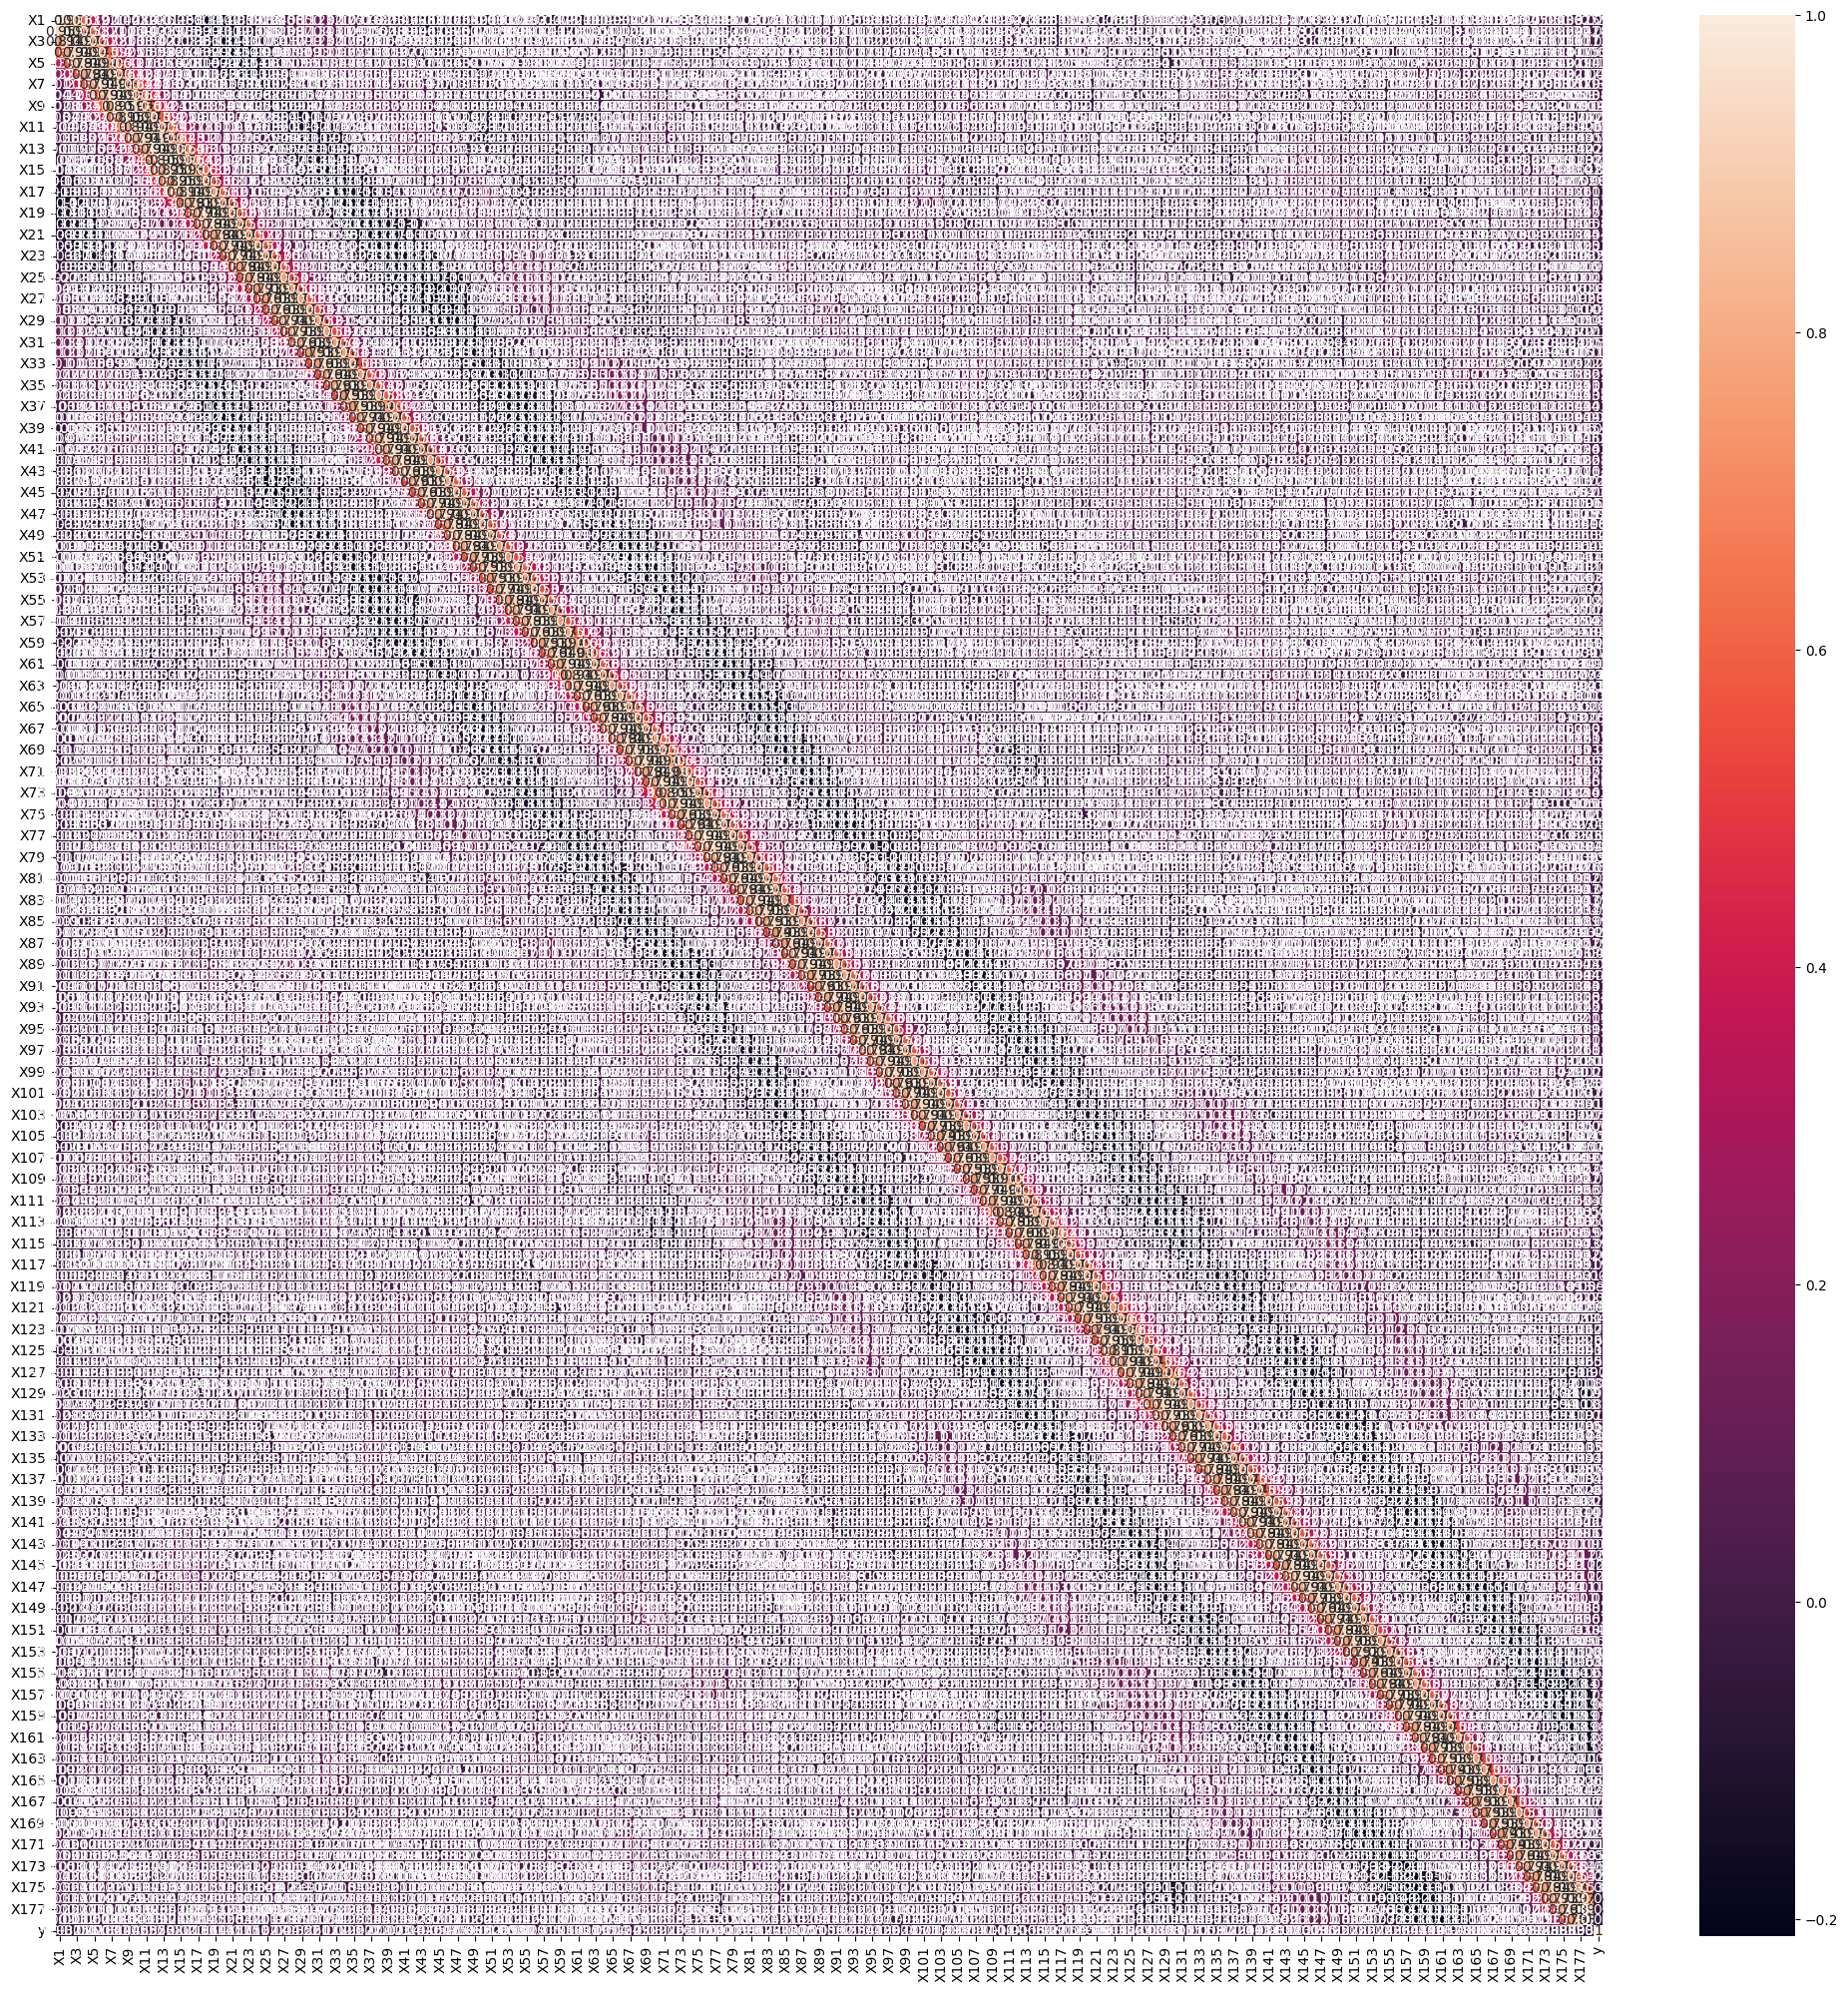

In [25]:
fig, ax = plt.subplots(figsize=(25, 25))
sns.heatmap(data.corr(), annot=True, ax=ax)

In [40]:
print('Number of records of Non Epileptic {0} VS Epilepttic {1}'.format(len(y == True), len(y == False)))

Number of records of Non Epileptic 11500 VS Epilepttic 11500


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)
he = X_train, X_test, y_train, y_test
[arr.shape for arr in he]

[(9200, 178), (2300, 178), (9200,), (2300,)]

In [42]:
models = [LogisticRegression(), SVC(),
          DecisionTreeClassifier(),
          RandomForestClassifier(), 
          GradientBoostingClassifier(),
          KNeighborsClassifier()]

#Check the correctness of list of classifiers and also 
model_name = [type(model).__name__ for model in models]
print(model_name)

# all parameters are not specified are set to their defaults
def classifiers(models):
    columns = ['Score', 'Predictions']
    df_result = pd.DataFrame(columns=columns, index=[type(model).__name__ for model in models])

    for model in models:
        clf = model
        print('Initialized classifier {} with default parameters \n'.format(type(model).__name__))    
        clf.fit(X_train, y_train)
        #make a predicitions for entire data(X_test)
        predictions = clf.predict(X_test)
        # Use score method to get accuracy of model
        score = clf.score(X_test, y_test)
        print('Score of classifier {} is: {} \n'.format(type(model).__name__, score))
        df_result['Score']['{}'.format(type(model).__name__)] = str(round(score * 100, 2)) + '%' 
        df_result['Predictions']['{}'.format(type(model).__name__)] = predictions
    return df_result

['LogisticRegression', 'SVC', 'DecisionTreeClassifier', 'RandomForestClassifier', 'GradientBoostingClassifier', 'KNeighborsClassifier']


In [43]:
classifiers(models)

Initialized classifier LogisticRegression with default parameters 



c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

C:\Users\hp\AppData\Local\Temp\ipykernel_14792\776173485.py:25: FutureWarning:

ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when y

Score of classifier LogisticRegression is: 0.6421739130434783 

Initialized classifier SVC with default parameters 

Score of classifier SVC is: 0.9786956521739131 

Initialized classifier DecisionTreeClassifier with default parameters 



C:\Users\hp\AppData\Local\Temp\ipykernel_14792\776173485.py:25: FutureWarning:

ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


C:\Users\hp\AppData\Local\Temp\ipykernel_14792\776173485.py:26: FutureWarning:

ChainedAssignmentError: behaviour will change in pa

Score of classifier DecisionTreeClassifier is: 0.9460869565217391 

Initialized classifier RandomForestClassifier with default parameters 



...

Score of classifier GradientBoostingClassifier is: 0.9665217391304348 

Initialized classifier KNeighborsClassifier with default parameters 



C:\Users\hp\AppData\Local\Temp\ipykernel_14792\776173485.py:25: FutureWarning:

ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


C:\Users\hp\AppData\Local\Temp\ipykernel_14792\776173485.py:26: FutureWarning:

ChainedAssignmentError: behaviour will change in pa

Score of classifier KNeighborsClassifier is: 0.9247826086956522 



C:\Users\hp\AppData\Local\Temp\ipykernel_14792\776173485.py:25: FutureWarning:

ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


C:\Users\hp\AppData\Local\Temp\ipykernel_14792\776173485.py:26: FutureWarning:

ChainedAssignmentError: behaviour will change in pa

,Score,Predictions
LogisticRegression,64.22%,"[0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, ..."
SVC,97.87%,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
DecisionTreeClassifier,94.61%,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, ..."
RandomForestClassifier,98.04%,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
GradientBoostingClassifier,96.65%,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
KNeighborsClassifier,92.48%,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [44]:
from sklearn.model_selection import KFold
model = RandomForestClassifier()
n_estimators = [10, 100, 1000]
max_features = ['sqrt', 'log2']
# define grid search
grid = dict(n_estimators=n_estimators,max_features=max_features)
cv = KFold(n_splits=3, random_state=None)
grid_search = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)
grid_result = grid_search.fit(X_train, y_train)
# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.971739 using {'max_features': 'sqrt', 'n_estimators': 1000}
0.964348 (0.003849) with: {'max_features': 'sqrt', 'n_estimators': 10}
0.968587 (0.001771) with: {'max_features': 'sqrt', 'n_estimators': 100}
0.971739 (0.001924) with: {'max_features': 'sqrt', 'n_estimators': 1000}
0.961848 (0.002624) with: {'max_features': 'log2', 'n_estimators': 10}
0.970544 (0.003026) with: {'max_features': 'log2', 'n_estimators': 100}
0.970652 (0.003021) with: {'max_features': 'log2', 'n_estimators': 1000}


In [45]:
model=model.fit(X_train,y_train)

In [46]:
pred=model.predict(X_test)

In [47]:
from sklearn.metrics import classification_report,confusion_matrix

In [48]:
print("Confusion Matrix:\n",confusion_matrix(y_test,pred))
print("Classification Report:\n",classification_report(y_test,pred))

Confusion Matrix:
 [[1814   21]
 [  25  440]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1835
           1       0.95      0.95      0.95       465

    accuracy                           0.98      2300
   macro avg       0.97      0.97      0.97      2300
weighted avg       0.98      0.98      0.98      2300



In [49]:
import pickle
pickle.dump(model, open('pipelinemodel.pkl','wb'))

In [50]:
pickle.load(open('pipelinemodel.pkl','rb'))

RandomForestClassifier()